# FirstLight Quantitative Commercial Team: Technical Assessment
## Pumped-Hydro Dispatch Optimization, June 24, 2025

**Author:** Pratik &nbsp;·&nbsp; **Asset:** 1,000 MW / 8,000 MWh pumped hydro at Mass Hub &nbsp;·&nbsp; **Market:** ISO-NE

---

### Table of Contents
1. [Executive Summary](#1-executive-summary)
2. [Methodology](#2-methodology)
3. [Key Assumptions](#3-key-assumptions)
4. [Results](#4-results)
5. [Verification and Sanity Checks](#5-verification-and-sanity-checks)
6. [Discussion: Real-World Implementation Considerations](#6-discussion-real-world-implementation-considerations)
7. [Files Produced](#7-files-produced)

<a id='1-executive-summary'></a>
## 1. Executive Summary

This analysis solves the optimal one-day dispatch problem for a 1,000 MW / 8,000 MWh pumped-hydro asset at Mass Hub on **June 24, 2025**. The asset chooses one of four mutually exclusive actions each hour: pump, generate, clear TMNSR, or idle: across the DA energy and DA Ancillary Services markets. The optimization is solved by **dynamic programming with perfect foresight** over a discrete (hour × storage) state space.

**Optimal total revenue: \$2,318,210.** The optimal policy pumps for 8 consecutive hours during cheap overnight prices (hours 0–7), clears TMNSR for 10 hours across the late-morning and afternoon (hours 8–15 and 22–23), and generates for 6 consecutive hours into the evening peak (hours 16–21). DA energy generation contributes \$2.15M of gross revenue against \$376K of pumping cost; TMNSR adds \$547K. The reservoir fills to 6,000 MWh and drains to zero by midnight.

*Note: the TMNSR settlement formula was corrected mid-assessment to the standard ISO-NE call-option form: closeout floored at zero, net revenue unfloored. The figures above reflect the corrected formula.*

<a id='2-methodology'></a>
## 2. Methodology

### Why dynamic programming?
Dispatch is an **inter-temporal** problem: storing energy in hour 3 only pays off if the price spread to a future generation hour exceeds the round-trip efficiency loss. Greedy rules ("pump when cheap, generate when expensive") fail because they can't trade off competing future opportunities. With perfect foresight and a discrete storage grid, DP solves the global optimum in time linear in (hours × states × actions): for this problem, well under a millisecond.

### State space
State is `(hour, storage_level)`:
- **Hours:** 0..23, plus a terminal hour 24 for the DP base case.
- **Storage levels:** multiples of 250 MWh in [0, 8000], so 33 discrete levels. The 250 MWh step is `GCD(750, 1000)`: the pump adds 750 MWh per hour and generation draws 1000 MWh per hour, so every reachable state lies on this grid.

Total state space: 24 × 33 = 792 cells (plus a terminal row), small enough for an exhaustive backward sweep.

### Action set, feasibility, and transitions

| Action | Feasibility | Storage transition |
|---|---|---|
| Pump | `s + 750 ≤ 8000` | `s → s + 750` |
| Generate | `s ≥ 1000` | `s → s − 1000` |
| TMNSR | always | `s → s` |
| Idle | always | `s → s` |

### Revenue formulas
Per hour `h`, with capacity `C = 1000` MW:

$$R_\text{pump}(h)     = -C \cdot \text{DA}_h \qquad R_\text{generate}(h) = +C \cdot \text{DA}_h$$
$$\text{closeout}(h)    = \max(\text{RT}_h - \text{Strike}_h,\ 0) \qquad R_\text{tmnsr}(h)    = C \cdot \bigl(\text{TMNSR}_h - \text{closeout}(h)\bigr) \qquad R_\text{idle}    = 0$$

**Note on the settlement.** DA A/S is settled as a **call option on real-time energy**. The closeout charge is the call payoff (≥ 0), and the cleared MW receives the TMNSR clearing price net of that payoff. The closeout is floored at zero, but the **net TMNSR revenue is not**: so when RT spikes well above the strike, the closeout exceeds the TMNSR clearing price and `R_tmnsr` is negative. In that regime, **idle dominates TMNSR**, which is why the DP must consider both.

### DP recurrence
Let `V[h][s]` be the maximum revenue achievable from hour `h` through hour 23 starting at storage `s`.

**Base case:** `V[24][s] = 0` for all `s` (terminal storage valued at zero).

**Backward recurrence** for `h = 23, 22, …, 0`:
$$V[h][s] = \max_{a \in \text{feasible}(s)} \bigl( R_a(h) + V[h+1][s'(s, a)] \bigr)$$

**Forward reconstruction** starts at `(h=0, s=0)` and follows the argmax policy through all 24 hours.

Demonstrate the revenue formulas on real hour-of-day numbers from the dataset.

In [ ]:
import os, sys
sys.path.insert(0, os.path.abspath(os.path.join('..')))
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src import revenue

prices = pd.read_csv('../data/prices_20250624.csv')
schedule = pd.read_csv('../data/dispatch_schedule_20250624.csv')

# Worked examples: one representative hour per action type
ex_pump = prices.iloc[4]      # cheap morning hour → pump
ex_gen  = prices.iloc[18]     # evening peak → generate
ex_tm   = prices.iloc[15]     # afternoon ramp → TMNSR (positive R_tmnsr)
ex_neg  = prices.iloc[18]     # evening peak → TMNSR would be deeply negative

print(f"Pump example     (hour {ex_pump.hour:>2.0f}): DA=${ex_pump.da_lmp:>7.2f}  →  R_pump     = {revenue.pump(ex_pump.da_lmp):>12,.2f}")
print(f"Generate example (hour {ex_gen.hour:>2.0f}): DA=${ex_gen.da_lmp:>7.2f}  →  R_generate = {revenue.generate(ex_gen.da_lmp):>12,.2f}")
print(f"TMNSR example    (hour {ex_tm.hour:>2.0f}): TMNSR=${ex_tm.tmnsr_price:>7.2f}, RT=${ex_tm.rt_lmp:>7.2f}, Strike=${ex_tm.tmnsr_strike:>7.2f}")
print(f"                   closeout = max(RT - Strike, 0) = {max(ex_tm.rt_lmp - ex_tm.tmnsr_strike, 0):>+8.2f}")
print(f"                   R_tmnsr  = 1000 · (TMNSR - closeout)        = {revenue.tmnsr(ex_tm.tmnsr_price, ex_tm.rt_lmp, ex_tm.tmnsr_strike):>12,.2f}")
print()
print(f"TMNSR (loss)     (hour {ex_neg.hour:>2.0f}): TMNSR=${ex_neg.tmnsr_price:>7.2f}, RT=${ex_neg.rt_lmp:>7.2f}, Strike=${ex_neg.tmnsr_strike:>7.2f}")
print(f"                   closeout = max(RT - Strike, 0) = {max(ex_neg.rt_lmp - ex_neg.tmnsr_strike, 0):>+8.2f}")
print(f"                   R_tmnsr would be                            = {revenue.tmnsr(ex_neg.tmnsr_price, ex_neg.rt_lmp, ex_neg.tmnsr_strike):>12,.2f}")
print(f"                   → optimizer correctly chooses generate, not TMNSR, in this hour")

Pump example     (hour  4): DA=$  41.23  →  R_pump     =   -41,230.00
Generate example (hour 18): DA=$ 474.90  →  R_generate =   474,900.00
TMNSR example    (hour 15): TMNSR=$ 237.16, RT=$ 183.69, Strike=$  91.37
                   closeout = max(RT - Strike, 0) =   +92.32
                   R_tmnsr  = 1000 · (TMNSR - closeout)        =   144,840.00

TMNSR (loss)     (hour 18): TMNSR=$ 429.47, RT=$1110.22, Strike=$ 114.39
                   closeout = max(RT - Strike, 0) =  +995.83
                   R_tmnsr would be                            =  -566,360.00
                   → optimizer correctly chooses generate, not TMNSR, in this hour


<a id='3-key-assumptions'></a>
## 3. Key Assumptions

- **Efficiency on the pump side.** 1,000 MWh purchased → 750 MWh stored; generation is 1:1. The optimum is invariant to which side carries the 75% RTE loss, but pump-side modeling yields a finer state grid (multiples of 250 MWh vs 1,000 MWh), which is more diagnostic.
- **One product per hour.** The asset cannot split capacity between DA energy and TMNSR within the same hour. Consistent with the required output schema.
- **Terminal storage valued at zero.** Appropriate for a single-day, standalone analysis. (A multi-day operation would need a continuation value.)
- **Perfect foresight** of DA LMP, RT LMP, TMNSR clearing prices, and DA A/S strike prices for the entire day.
- **Full-capacity dispatch only.** Pump, generate, and TMNSR all execute at 1,000 MW; no partial commitment.
- **No physical constraints.** No ramping limits, startup costs, minimum run/down times, or pump↔generate transition delays.
- **Price-taker.** The asset's bids do not move DA or RT prices.

<a id='4-results'></a>
## 4. Results

### Revenue breakdown

In [ ]:
total_rev = schedule['hourly_total_revenue'].sum()
gen_rev   = schedule.loc[schedule['action'] == 'generate', 'da_energy_revenue'].sum()
pump_cost = schedule.loc[schedule['action'] == 'pump',     'da_energy_revenue'].sum()
da_net    = schedule['da_energy_revenue'].sum()
tm_rev    = schedule['tmnsr_revenue'].sum()

breakdown = pd.DataFrame({
    'Item':   ['DA generation revenue', 'Pumping cost', 'Net DA energy revenue', 'TMNSR revenue', 'Total revenue'],
    'Amount': [gen_rev, pump_cost, da_net, tm_rev, total_rev],
})
breakdown['Amount'] = breakdown['Amount'].map(lambda x: f"${x:,.0f}")
breakdown.style.hide(axis='index')

Item,Amount
DA generation revenue,"$2,147,090"
Pumping cost,"$-375,670"
Net DA energy revenue,"$1,771,420"
TMNSR revenue,"$546,790"
Total revenue,"$2,318,210"


### Operational summary

In [ ]:
n_pump  = (schedule['action'] == 'pump').sum()
n_gen   = (schedule['action'] == 'generate').sum()
n_tmnsr = (schedule['action'] == 'tmnsr').sum()
n_idle  = (schedule['action'] == 'idle').sum()

mwh_consumed = n_pump * 1000
mwh_stored   = n_pump * 750
mwh_gen      = n_gen  * 1000
rte_realized = mwh_gen / mwh_consumed
ending_storage = int(schedule['storage_end_mwh'].iloc[-1])

pump_hours  = schedule.loc[schedule['action'] == 'pump',     'hour'].tolist()
gen_hours   = schedule.loc[schedule['action'] == 'generate', 'hour'].tolist()
tmnsr_hours = schedule.loc[schedule['action'] == 'tmnsr',    'hour'].tolist()

print(f"Hours pumping:       {n_pump}  (hours {pump_hours})")
print(f"Hours generating:    {n_gen}  (hours {gen_hours})")
print(f"Hours clearing TMNSR:{n_tmnsr}  (hours {tmnsr_hours})")
print(f"Hours idle:          {n_idle}")
print()
print(f"Total MWh consumed (grid draw): {mwh_consumed:>6,}")
print(f"Total MWh stored:               {mwh_stored:>6,}")
print(f"Total MWh generated:            {mwh_gen:>6,}")
print(f"Round-trip efficiency realized: {rte_realized:.0%}")
print(f"Ending storage:                 {ending_storage:>6,} MWh")

Hours pumping:       8  (hours [0, 1, 2, 3, 4, 5, 6, 7])
Hours generating:    6  (hours [16, 17, 18, 19, 20, 21])
Hours clearing TMNSR:10  (hours [8, 9, 10, 11, 12, 13, 14, 15, 22, 23])
Hours idle:          0

Total MWh consumed (grid draw):  8,000
Total MWh stored:                6,000
Total MWh generated:             6,000
Round-trip efficiency realized: 75%
Ending storage:                      0 MWh


### Price and dispatch timeline
DA LMP, hourly revenue colored by action, and storage trajectory: all on a shared hour axis.

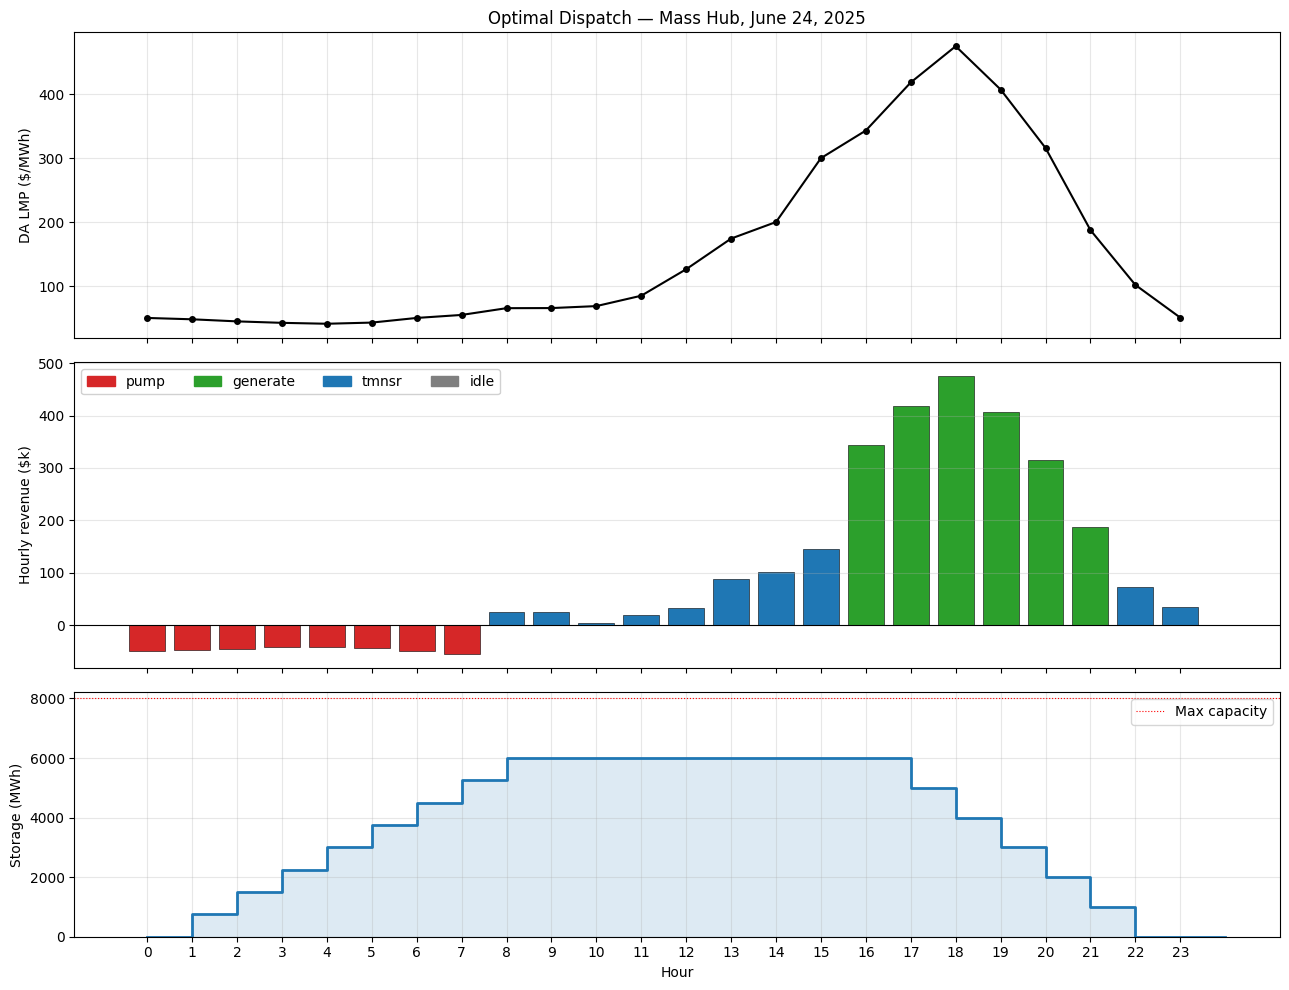

In [ ]:
ACTION_COLORS = {'pump': '#d62728', 'generate': '#2ca02c', 'tmnsr': '#1f77b4', 'idle': '#7f7f7f'}

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(13, 10), sharex=True,
                                     gridspec_kw={'height_ratios': [2, 2, 1.6]})

# Top: DA LMP
ax1.plot(prices['hour'], prices['da_lmp'], color='black', lw=1.5, marker='o', markersize=4)
ax1.set_ylabel('DA LMP ($/MWh)')
ax1.set_title('Optimal Dispatch: Mass Hub, June 24, 2025')
ax1.grid(True, alpha=0.3)

# Middle: hourly revenue bars by action
bar_colors = [ACTION_COLORS[a] for a in schedule['action']]
ax2.bar(schedule['hour'], schedule['hourly_total_revenue'] / 1000, color=bar_colors, edgecolor='black', linewidth=0.4)
ax2.axhline(0, color='black', lw=0.8)
ax2.set_ylabel('Hourly revenue ($k)')
ax2.grid(True, alpha=0.3, axis='y')
handles = [plt.Rectangle((0, 0), 1, 1, color=c, label=a) for a, c in ACTION_COLORS.items()]
ax2.legend(handles=handles, loc='upper left', framealpha=0.9, ncol=4)

# Bottom: storage trajectory
storage_series = pd.concat([
    pd.DataFrame({'hour': [0], 'storage': [0]}),
    schedule[['hour', 'storage_end_mwh']].rename(columns={'storage_end_mwh': 'storage'}).assign(hour=lambda d: d['hour'] + 1)
])
ax3.plot(storage_series['hour'], storage_series['storage'], drawstyle='steps-post', color='#1f77b4', lw=2)
ax3.fill_between(storage_series['hour'], storage_series['storage'], step='post', alpha=0.15, color='#1f77b4')
ax3.set_ylabel('Storage (MWh)')
ax3.set_xlabel('Hour')
ax3.set_xticks(range(24))
ax3.set_ylim(0, 8200)
ax3.axhline(8000, color='red', ls=':', lw=0.8, label='Max capacity')
ax3.legend(loc='upper right')
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Cumulative revenue progression
Hour markers colored by action show where the cumulative curve gains, loses, or holds.

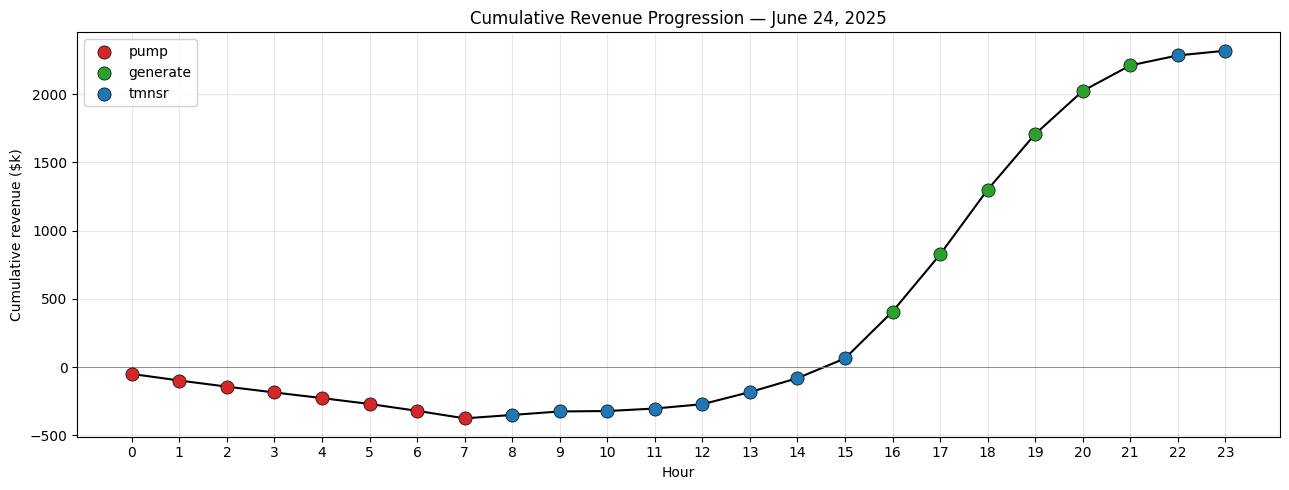

In [ ]:
fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(schedule['hour'], schedule['cumulative_revenue'] / 1000, color='black', lw=1.5, zorder=2)
for action, color in ACTION_COLORS.items():
    mask = schedule['action'] == action
    if mask.any():
        ax.scatter(schedule.loc[mask, 'hour'], schedule.loc[mask, 'cumulative_revenue'] / 1000,
                   color=color, s=90, label=action, zorder=3, edgecolor='black', linewidth=0.5)
ax.axhline(0, color='gray', lw=0.6)
ax.set_xlabel('Hour')
ax.set_ylabel('Cumulative revenue ($k)')
ax.set_title('Cumulative Revenue Progression: June 24, 2025')
ax.set_xticks(range(24))
ax.legend(loc='upper left', framealpha=0.9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

<a id='5-verification-and-sanity-checks'></a>
## 5. Verification and Sanity Checks

In [ ]:
from src.dispatch_optimizer import optimize

# Re-run the DP so we can compare the schedule total to V[0][0].
result = optimize(prices)

checks = []

# 1. Revenue formula spot-checks: one per action, using the corrected TMNSR formula
p4, p18, p15 = prices.iloc[4], prices.iloc[18], prices.iloc[15]
assert revenue.pump(p4.da_lmp)     == -1000 * p4.da_lmp
assert revenue.generate(p18.da_lmp) ==  1000 * p18.da_lmp
expected_tmnsr = 1000 * (p15.tmnsr_price - max(p15.rt_lmp - p15.tmnsr_strike, 0))
assert revenue.tmnsr(p15.tmnsr_price, p15.rt_lmp, p15.tmnsr_strike) == expected_tmnsr
checks.append('Revenue formulas verified by manual calculation (pump, generate, TMNSR call-option settlement)')

# 2. Reconciliation
assert np.isclose(da_net + tm_rev, total_rev)
checks.append(f'Total revenue reconciles: net DA (${da_net:,.0f}) + TMNSR (${tm_rev:,.0f}) = ${total_rev:,.0f}')

# 3. Energy balance
assert mwh_consumed * 0.75 == mwh_stored == mwh_gen
checks.append(f'Energy balance: {mwh_consumed:,} MWh consumed × 0.75 = {mwh_stored:,} MWh stored = {mwh_gen:,} MWh generated')

# 4. Storage bounds
assert (schedule['storage_start_mwh'].between(0, 8000)).all()
assert (schedule['storage_end_mwh'].between(0, 8000)).all()
checks.append('Storage stays within [0, 8000] MWh in every hour')

# 5. Transition consistency
deltas = schedule['storage_end_mwh'] - schedule['storage_start_mwh']
for d, a in zip(deltas, schedule['action']):
    expected = {'pump': 750, 'generate': -1000, 'tmnsr': 0, 'idle': 0}[a]
    assert d == expected
checks.append('Every storage transition matches the action taken that hour')

# 6. Idle is only optimal when R_tmnsr <= 0 (under call-option settlement, TMNSR can be negative)
for _, row in schedule.iterrows():
    if row['action'] == 'idle':
        h = int(row['hour']); pr = prices.iloc[h]
        assert revenue.tmnsr(pr.tmnsr_price, pr.rt_lmp, pr.tmnsr_strike) <= 0
checks.append(f'Idle action only chosen when R_tmnsr ≤ 0 ({n_idle} idle hours on June 24)')

# 7. Schedule total matches V[0][0]
assert np.isclose(total_rev, result.v0)
checks.append(f'Schedule total (${total_rev:,.0f}) equals V[0][0] (${result.v0:,.0f}) from the DP table')

for c in checks:
    print(f'✅ {c}')

✅ Revenue formulas verified by manual calculation (pump, generate, TMNSR call-option settlement)
✅ Total revenue reconciles: net DA ($1,771,420) + TMNSR ($546,790) = $2,318,210
✅ Energy balance: 8,000 MWh consumed × 0.75 = 6,000 MWh stored = 6,000 MWh generated
✅ Storage stays within [0, 8000] MWh in every hour
✅ Every storage transition matches the action taken that hour
✅ Idle action only chosen when R_tmnsr ≤ 0 (0 idle hours on June 24)
✅ Schedule total ($2,318,210) equals V[0][0] ($2,318,210) from the DP table


<a id='6-discussion-real-world-implementation-considerations'></a>
## 6. Discussion: Real-World Implementation Considerations

The deterministic optimum reported here is a useful *upper bound* on what a real desk could earn on June 24, 2025. The gap between this number and what a live operation actually realizes comes from the following sources.

### Perfect foresight vs forecasting
The DP assumes exact knowledge of every DA LMP, RT LMP, TMNSR clearing price, and strike price before any decision is made. In practice, DA bids are submitted before RT outcomes are known, so the TMNSR closeout (a call payoff on RT) is a *random variable* at decision time, and the evening peak's magnitude and timing are forecasts. The call-option structure of TMNSR makes this especially important: a single RT spike above the strike can flip a TMNSR hour from positive to deeply negative revenue. A production system would replace deterministic DP with **stochastic DP, scenario-tree optimization, or robust optimization** over price distributions and would re-solve intra-day as RT prices arrive.

### Single-day horizon
Terminal storage is valued at zero, so the optimizer fully drains the reservoir by midnight. A multi-day operator would carry a **continuation value** `W(s)` derived from forward curves and would not drain if next-day expected prices justified holding inventory. This would most likely shift the last 1–2 generate hours back toward TMNSR or idle.

### No partial dispatch
Real pumped hydro can split capacity *within an hour*: e.g., bid 700 MW into DA energy and 300 MW into TMNSR. The single-product-per-hour restriction is a modeling simplification that strictly under-counts revenue. Allowing split dispatch would expand the action space but is straightforward to add to the DP.

### Physical constraints ignored
The model has no **ramp limits, startup/shutdown costs, minimum run/down times, or pump↔generate transition delays.** A pump-storage unit typically cannot flip from full-pump to full-generate within a single hour without water-management or unit-trip costs. Adding these constraints requires lifting the state to include the current operating mode and any minimum-time counters.

### TMNSR inventory coupling
The model treats TMNSR as a pure financial product that does not draw storage. In reality, a reserve sale is a *contingent commitment to deliver energy if called*. Honoring a call would deplete the reservoir, and the probability of being called is itself state- and time-dependent. A faithful model would couple TMNSR cleared MW to expected energy delivery and tie that into the storage transition.

### Call-option settlement: implications for strategy
With the corrected settlement, TMNSR revenue is `C · (TMNSR − max(RT − Strike, 0))`: the cleared MW receives the reserve clearing price net of a call payoff on real-time energy. Three implications worth flagging:
- **Net revenue is unbounded below.** When RT spikes far above the strike (e.g., hour 18 on June 24, with RT = \$1,110 and Strike = \$114), the closeout dwarfs the TMNSR price and clearing TMNSR would lose hundreds of thousands of dollars. The optimal policy correctly avoids TMNSR in those hours.
- **Idle is no longer dominated.** Under the previous (incorrect) formulation where `R_tmnsr` was floored at zero, idle was weakly dominated everywhere. Under the corrected formulation, the DP must actively choose between TMNSR (positive expected reserve payment, but tail-risk on the closeout) and idle. On June 24, every hour's TMNSR payoff was positive, so the optimum still has zero idle hours: but on a higher-RT-volatility day, that would change.
- **A risk-aware bidder would shade TMNSR cleared MW** below 1,000 MW in hours with a fat right tail on RT, even when expected revenue is positive: exactly the kind of decision a stochastic formulation handles natively.

### Market impact
A 1,000 MW asset is large enough to **move DA and RT prices through its own bidding**: the price-taker assumption breaks. Real bidding strategy would model own-impact and likely under-bid versus the perfect-foresight schedule to avoid self-cannibalization, particularly during the evening peak hours when the asset is dispatching its full 1 GW.

### Operational risks
Equipment failures, forecast errors, regulatory changes, and **basis risk** (Mass Hub price ≠ delivery-node price) all create deviations from the deterministic optimum. A real desk would carry reserves of opportunity and avoid concentrating exposure in any single hour.

<a id='7-files-produced'></a>
## 7. Files Produced

| Path | Purpose |
|---|---|
| `data/prices_20250624.csv` | Raw price data fetched from ISO-NE Web API (DA LMP, RT LMP, TMNSR, strike) |
| `data/dispatch_schedule_20250624.csv` | Optimal 24-hour dispatch schedule |
| `figures/dispatch_20250624.png` | Dispatch visualization (price + revenue + storage) |
| `src/fetch_data.py` | ISO-NE API data retrieval (4 endpoints → tidy DataFrames) |
| `src/revenue.py` | Per-action revenue formulas |
| `src/dispatch_optimizer.py` | DP engine: backward recurrence + forward reconstruction |
| `scripts/fetch_data.py` | Orchestration for Step 1 (fetch + merge + save) |
| `scripts/optimize_dispatch.py` | Orchestration for Step 2 (load + optimize + verify + plot) |
| `notebooks/03_submission_writeup.ipynb` | This notebook: technical writeup and analysis |